# 1. Problem definition

**Objective:** Predict house prices per square meter (`Giá/m2`) in the Vietnamese housing market using property features.

**Problem Type:** Regression

**Business Goal:** Help buyers and sellers estimate fair property prices based on location, size, and property characteristics.

# 2. Dataset source

**Dataset:** `VN_housing_dataset.csv`

**Source:** Vietnamese real estate listings from Hanoi market (2020)

**Size:** ~82,000 property records with features including location, size, property type, and price per m².

# 3. Dataset loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

In [2]:
# Load dataset
df = pd.read_csv('../VN_housing_dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"Total records: {len(df):,}")

Dataset shape: (82497, 13)
Total records: 82,497


# 4. Dataset inspection

In [3]:
print("Column names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst few rows:")
df.head()

Column names:
['Unnamed: 0', 'Ngày', 'Địa chỉ', 'Quận', 'Huyện', 'Loại hình nhà ở', 'Giấy tờ pháp lý', 'Số tầng', 'Số phòng ngủ', 'Diện tích', 'Dài', 'Rộng', 'Giá/m2']

Data types:
Unnamed: 0         float64
Ngày                   str
Địa chỉ                str
Quận                   str
Huyện                  str
Loại hình nhà ở        str
Giấy tờ pháp lý        str
Số tầng                str
Số phòng ngủ           str
Diện tích              str
Dài                    str
Rộng                   str
Giá/m2                 str
dtype: object

First few rows:


,Unnamed: 0,Ngày,Địa chỉ,Quận,Huyện,Loại hình nhà ở,Giấy tờ pháp lý,Số tầng,Số phòng ngủ,Diện tích,Dài,Rộng,Giá/m2
0,0.0,2020-08-05,"Đường Hoàng Quốc Việt, Phường Nghĩa Đô, Quận C...",Quận Cầu Giấy,Phường Nghĩa Đô,"Nhà ngõ, hẻm",Đã có sổ,4,5 phòng,46 m²,NaN,NaN,"86,96 triệu/m²"
1,1.0,2020-08-05,"Đường Kim Giang, Phường Kim Giang, Quận Thanh ...",Quận Thanh Xuân,Phường Kim Giang,"Nhà mặt phố, mặt tiền",NaN,NaN,3 phòng,37 m²,NaN,NaN,"116,22 triệu/m²"
2,2.0,2020-08-05,"phố minh khai, Phường Minh Khai, Quận Hai Bà T...",Quận Hai Bà Trưng,Phường Minh Khai,"Nhà ngõ, hẻm",Đã có sổ,4,4 phòng,40 m²,10 m,4 m,65 triệu/m²
3,3.0,2020-08-05,"Đường Võng Thị, Phường Thụy Khuê, Quận Tây Hồ,...",Quận Tây Hồ,Phường Thụy Khuê,"Nhà ngõ, hẻm",Đã có sổ,NaN,6 phòng,51 m²,12.75 m,4 m,100 triệu/m²
4,4.0,2020-08-05,"Đường Kim Giang, Phường Kim Giang, Quận Thanh ...",Quận Thanh Xuân,Phường Kim Giang,"Nhà ngõ, hẻm",NaN,NaN,4 phòng,36 m²,9 m,4 m,"86,11 triệu/m²"


In [4]:
print("Sample record (raw observation):")
df.iloc[0]

Sample record (raw observation):


Unnamed: 0                                                       0.0
Ngày                                                      2020-08-05
Địa chỉ            Đường Hoàng Quốc Việt, Phường Nghĩa Đô, Quận C...
Quận                                                   Quận Cầu Giấy
Huyện                                                Phường Nghĩa Đô
Loại hình nhà ở                                         Nhà ngõ, hẻm
Giấy tờ pháp lý                                             Đã có sổ
Số tầng                                                            4
Số phòng ngủ                                                 5 phòng
Diện tích                                                      46 m²
Dài                                                              NaN
Rộng                                                             NaN
Giá/m2                                                86,96 triệu/m²
Name: 0, dtype: object

# 5. Data-quality analysis

In [6]:
# Data quality overview
quality_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing %': (df.isnull().sum() / len(df) * 100).values,
    'Unique': df.nunique().values,
    'Dtype': df.dtypes.values
})

print(quality_summary.to_string())

             Column  Missing %  Unique    Dtype
0        Unnamed: 0   0.001212   82496  float64
1              Ngày   0.001212     174      str
2           Địa chỉ   0.058184   13957      str
3              Quận   0.002424      29      str
4             Huyện   0.058184     309      str
5   Loại hình nhà ở   0.038789       4      str
6   Giấy tờ pháp lý  35.015819       3      str
7           Số tầng  55.878396      29      str
8      Số phòng ngủ   0.047274      11      str
9         Diện tích   0.002424     504      str
10              Dài  75.966399     487      str
11             Rộng  57.034801     410      str
12           Giá/m2   0.015758    8345      str


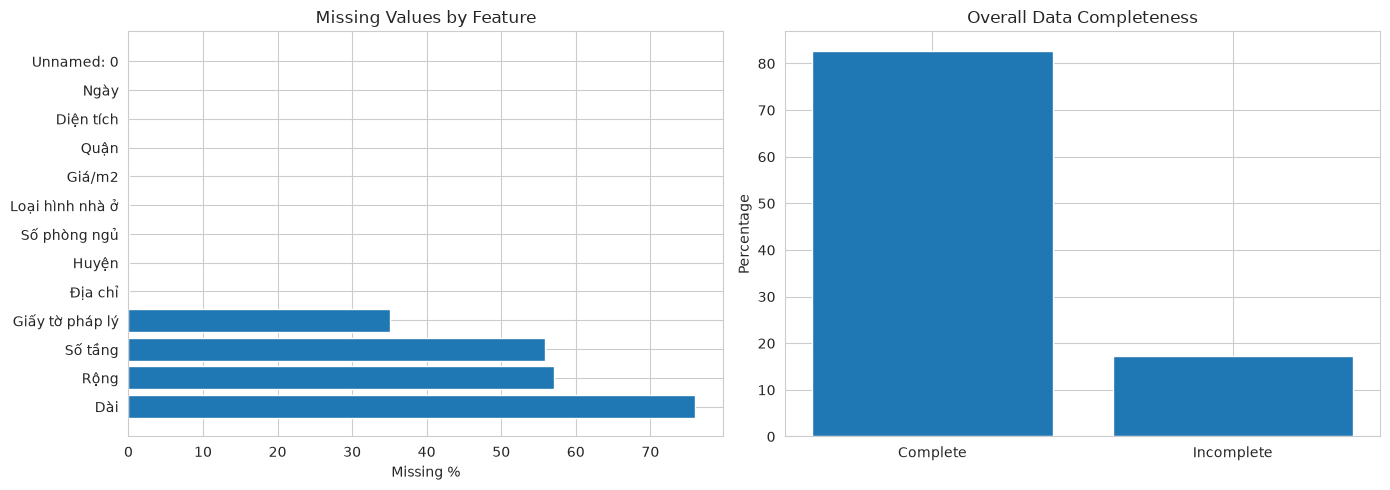

Average completeness: 82.76%


In [7]:
# Visualize data quality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing value percentage
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
axes[0].barh(range(len(missing_pct)), missing_pct.values)
axes[0].set_yticks(range(len(missing_pct)))
axes[0].set_yticklabels(missing_pct.index)
axes[0].set_xlabel('Missing %')
axes[0].set_title('Missing Values by Feature')

# Data completeness
complete_pct = (1 - df.isnull().sum() / len(df)) * 100
axes[1].bar(['Complete', 'Incomplete'], 
            [complete_pct.mean(), 100 - complete_pct.mean()])
axes[1].set_ylabel('Percentage')
axes[1].set_title('Overall Data Completeness')

plt.tight_layout()
plt.show()

print(f"Average completeness: {complete_pct.mean():.2f}%")

# 6. Missing-value analysis

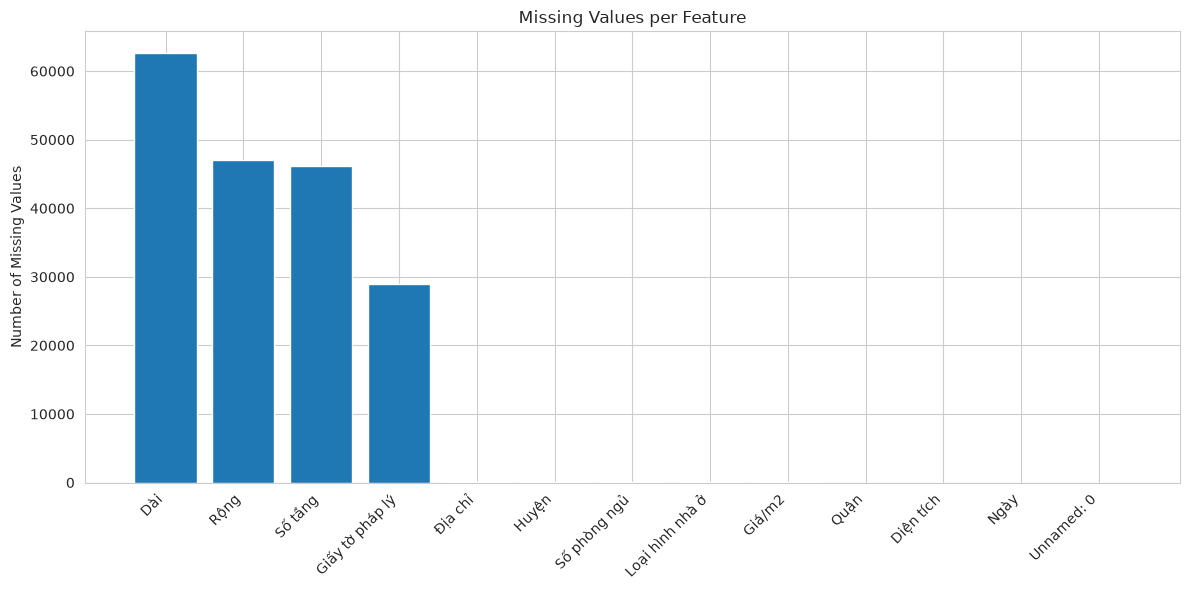


Missing value summary:
Dài: 62,670 (75.97%)
Rộng: 47,052 (57.03%)
Số tầng: 46,098 (55.88%)
Giấy tờ pháp lý: 28,887 (35.02%)
Địa chỉ: 48 (0.06%)
Huyện: 48 (0.06%)
Số phòng ngủ: 39 (0.05%)
Loại hình nhà ở: 32 (0.04%)
Giá/m2: 13 (0.02%)
Quận: 2 (0.00%)
Diện tích: 2 (0.00%)
Ngày: 1 (0.00%)
Unnamed: 0: 1 (0.00%)


In [8]:
# Missing value analysis
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(range(len(missing_data)), missing_data.values)
plt.xticks(range(len(missing_data)), missing_data.index, rotation=45, ha='right')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values per Feature')
plt.tight_layout()
plt.show()

print("\nMissing value summary:")
for col, count in missing_data.items():
    print(f"{col}: {count:,} ({count/len(df)*100:.2f}%)")

# 7. Duplicate analysis

Number of duplicate rows: 0
Duplicate percentage: 0.00%


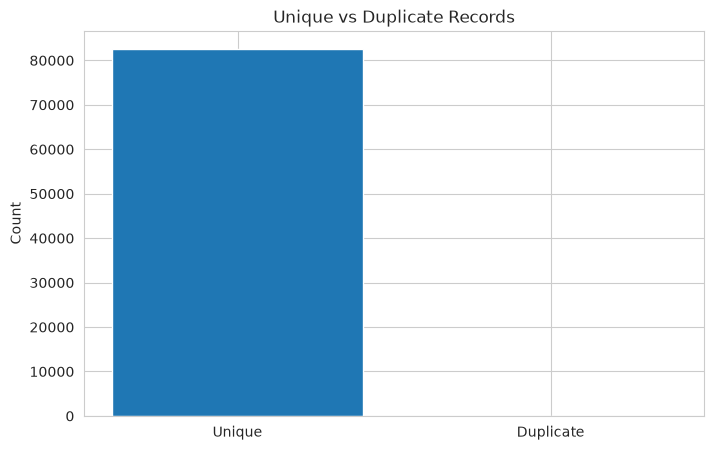

In [9]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print(f"Duplicate percentage: {duplicates/len(df)*100:.2f}%")

# Visualize
plt.figure(figsize=(8, 5))
plt.bar(['Unique', 'Duplicate'], [len(df) - duplicates, duplicates])
plt.ylabel('Count')
plt.title('Unique vs Duplicate Records')
plt.show()

# 8. Invalid-value analysis

In [10]:
# Parse price column (Vietnamese format with 'triệu/m²')
def parse_price(price_str):
    if pd.isna(price_str):
        return np.nan
    try:
        # Remove 'triệu/m²' and convert comma to dot
        price_clean = str(price_str).replace(' triệu/m²', '').replace(',', '.')
        return float(price_clean)
    except:
        return np.nan

# Parse area column
def parse_area(area_str):
    if pd.isna(area_str):
        return np.nan
    try:
        area_clean = str(area_str).replace(' m²', '').replace(',', '.')
        return float(area_clean)
    except:
        return np.nan

# Parse dimension columns (Dài, Rộng)
def parse_dimension(dim_str):
    if pd.isna(dim_str):
        return np.nan
    try:
        dim_clean = str(dim_str).replace(' m', '').replace(',', '.')
        return float(dim_clean)
    except:
        return np.nan

# Apply parsing
df['Price_per_m2'] = df['Giá/m2'].apply(parse_price)
df['Area'] = df['Diện tích'].apply(parse_area)
df['Length'] = df['Dài'].apply(parse_dimension)
df['Width'] = df['Rộng'].apply(parse_dimension)

print("Parsed numerical features:")
print(df[['Price_per_m2', 'Area', 'Length', 'Width']].describe())

Parsed numerical features:
       Price_per_m2           Area         Length          Width
count  81626.000000   82495.000000   19827.000000   35445.000000
mean     102.511676      51.364438      89.759940      37.814743
std       63.214775     470.675198    6468.978073    3101.428641
min        1.000000       1.000000       1.000000       1.000000
25%       73.330000      34.000000       8.000000       4.000000
50%       90.000000      40.000000      10.000000       4.000000
75%      110.710000      50.000000      12.000000       5.000000
max      998.000000  111411.000000  900000.000000  423432.000000


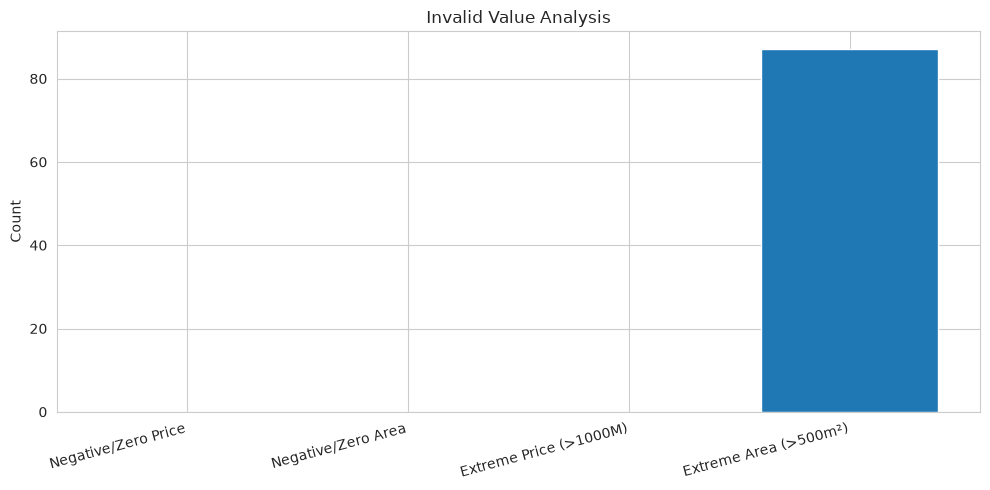

Negative/Zero Price: 0 (0.00%)
Negative/Zero Area: 0 (0.00%)
Extreme Price (>1000M): 0 (0.00%)
Extreme Area (>500m²): 87 (0.11%)


In [11]:
# Check for invalid values
invalid_counts = {
    'Negative/Zero Price': (df['Price_per_m2'] <= 0).sum(),
    'Negative/Zero Area': (df['Area'] <= 0).sum(),
    'Extreme Price (>1000M)': (df['Price_per_m2'] > 1000).sum(),
    'Extreme Area (>500m²)': (df['Area'] > 500).sum()
}

plt.figure(figsize=(10, 5))
plt.bar(invalid_counts.keys(), invalid_counts.values())
plt.ylabel('Count')
plt.title('Invalid Value Analysis')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

for k, v in invalid_counts.items():
    print(f"{k}: {v} ({v/len(df)*100:.2f}%)")

# 9. Outlier analysis

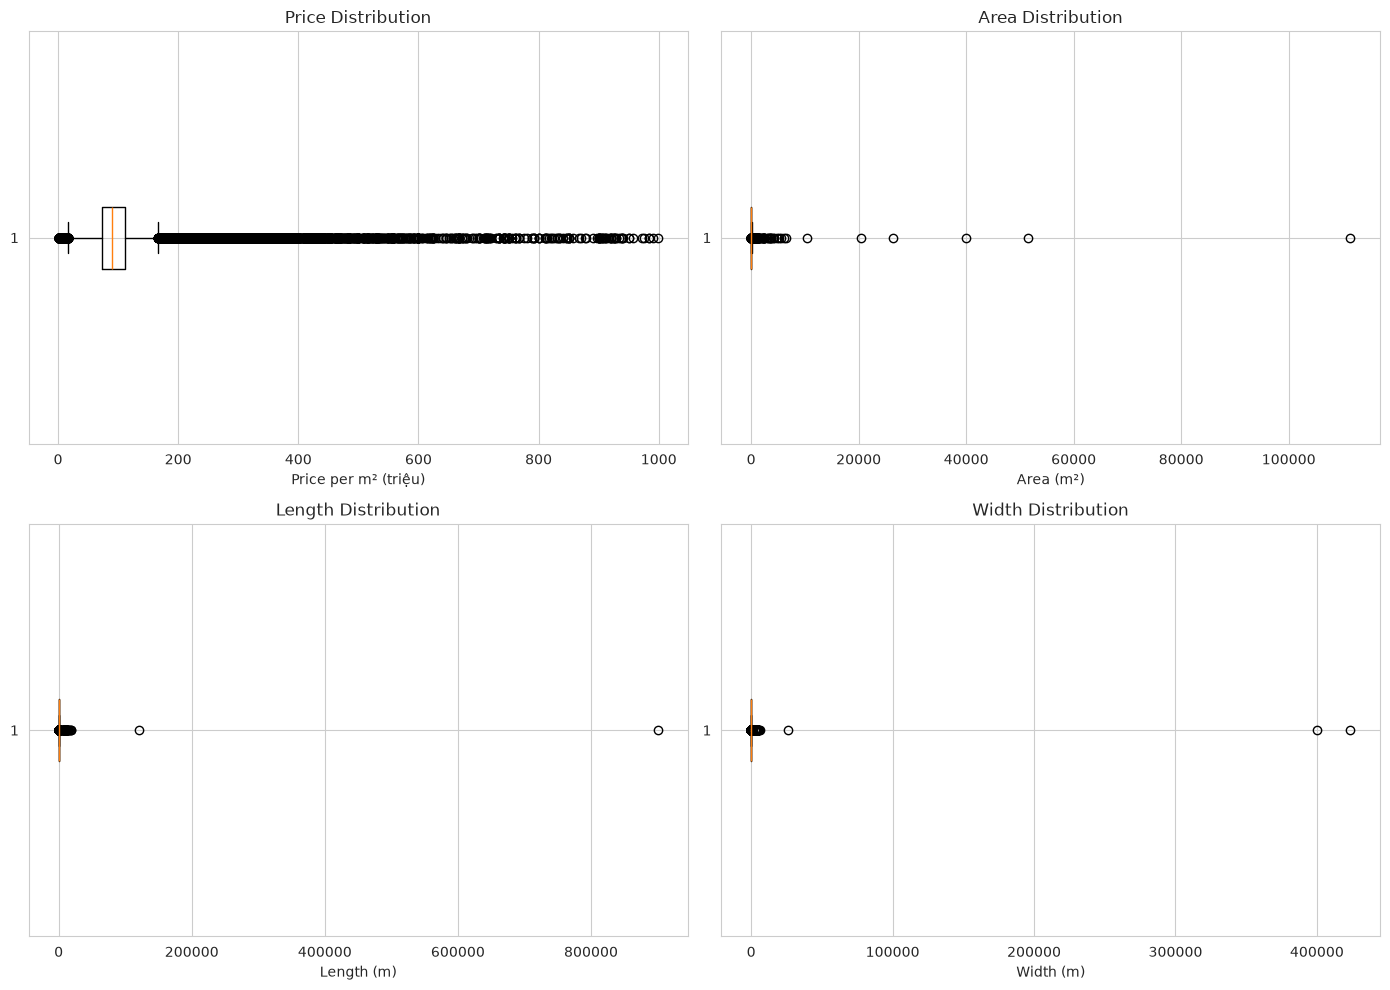

Price_per_m2: 6967 outliers (8.45%)
Area: 6112 outliers (7.41%)
Length: 1268 outliers (1.54%)
Width: 3825 outliers (4.64%)


In [12]:
# Boxplot for key numerical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].boxplot(df['Price_per_m2'].dropna(), vert=False)
axes[0, 0].set_xlabel('Price per m² (triệu)')
axes[0, 0].set_title('Price Distribution')

axes[0, 1].boxplot(df['Area'].dropna(), vert=False)
axes[0, 1].set_xlabel('Area (m²)')
axes[0, 1].set_title('Area Distribution')

axes[1, 0].boxplot(df['Length'].dropna(), vert=False)
axes[1, 0].set_xlabel('Length (m)')
axes[1, 0].set_title('Length Distribution')

axes[1, 1].boxplot(df['Width'].dropna(), vert=False)
axes[1, 1].set_xlabel('Width (m)')
axes[1, 1].set_title('Width Distribution')

plt.tight_layout()
plt.show()

# Outlier statistics using IQR method
for col in ['Price_per_m2', 'Area', 'Length', 'Width']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)")

# 10. Exploratory data analysis

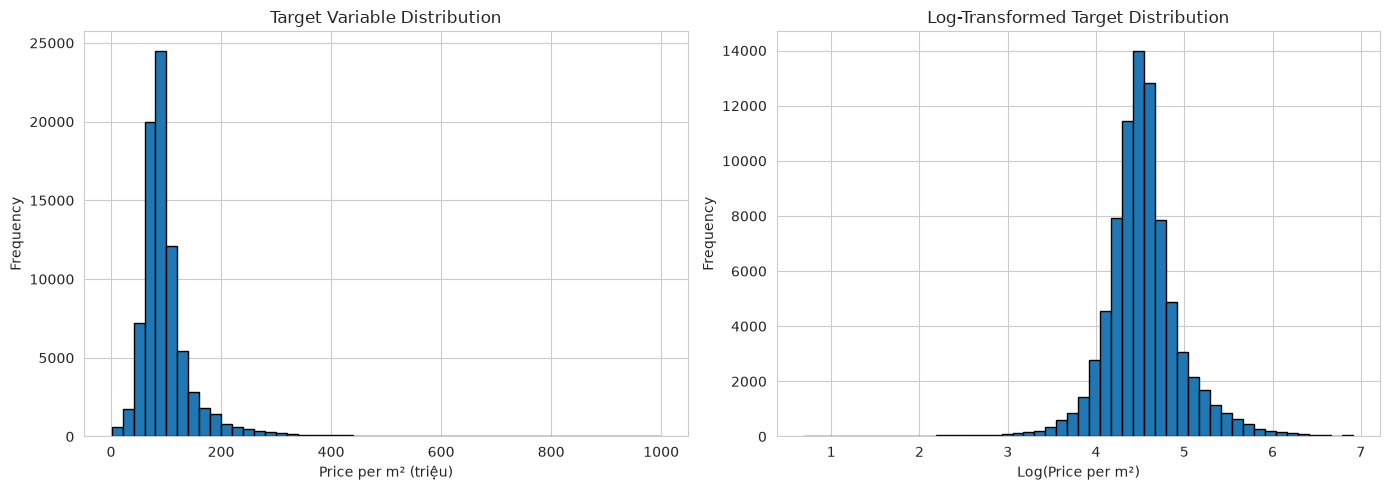

Price statistics:
count    81626.000000
mean       102.511676
std         63.214775
min          1.000000
25%         73.330000
50%         90.000000
75%        110.710000
max        998.000000
Name: Price_per_m2, dtype: float64


In [13]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Price_per_m2'].dropna(), bins=50, edgecolor='black')
axes[0].set_xlabel('Price per m² (triệu)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Variable Distribution')

axes[1].hist(np.log1p(df['Price_per_m2'].dropna()), bins=50, edgecolor='black')
axes[1].set_xlabel('Log(Price per m²)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Log-Transformed Target Distribution')

plt.tight_layout()
plt.show()

print(f"Price statistics:")
print(df['Price_per_m2'].describe())

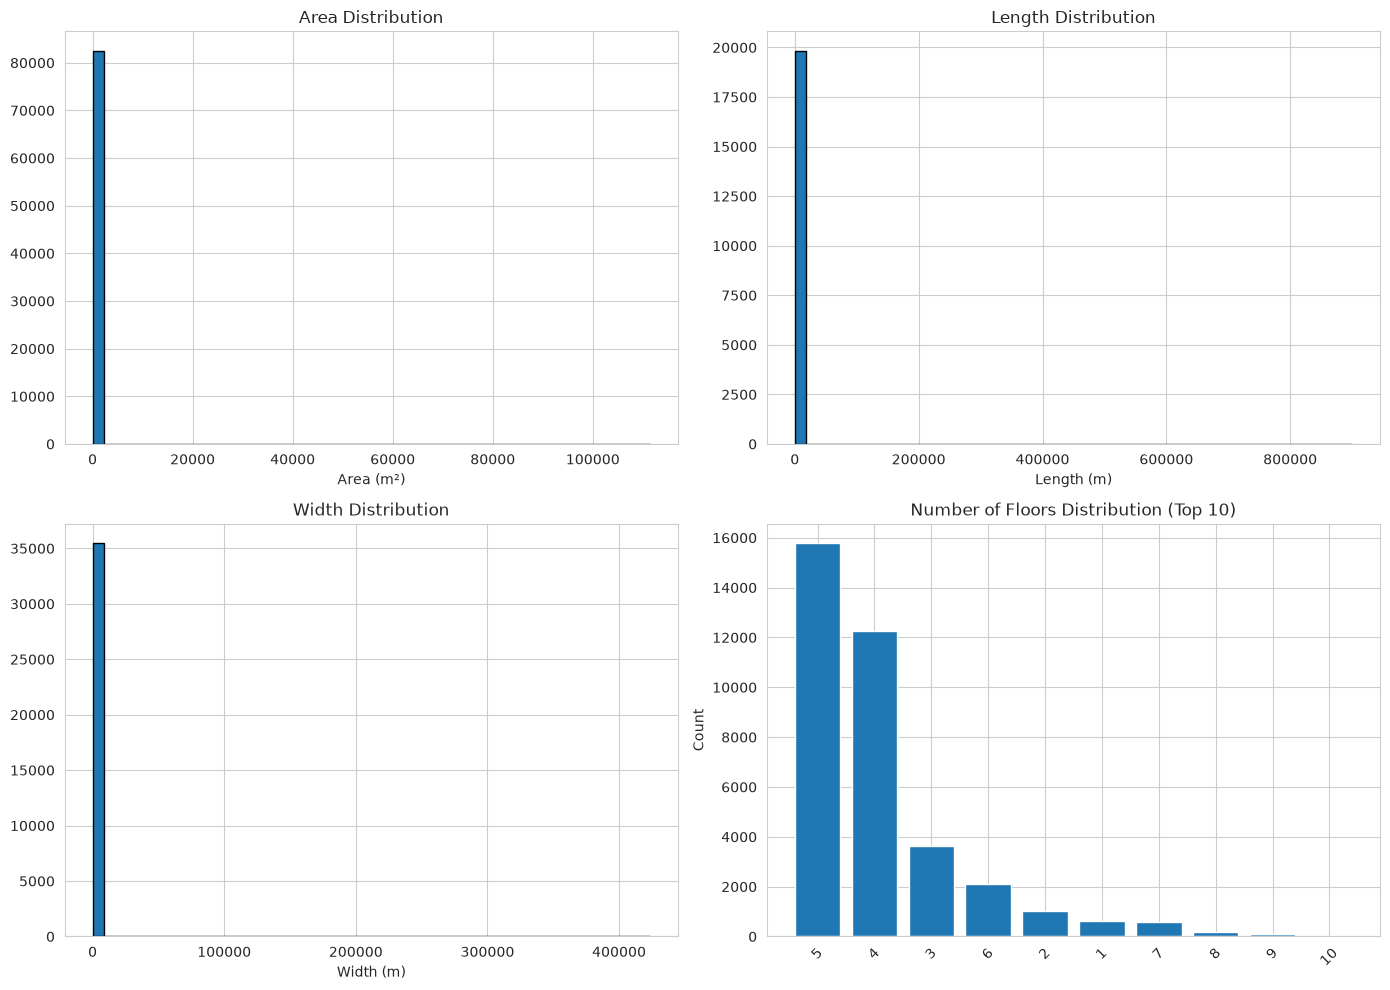

In [14]:
# Numerical features distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['Area'].dropna(), bins=50, edgecolor='black')
axes[0, 0].set_xlabel('Area (m²)')
axes[0, 0].set_title('Area Distribution')

axes[0, 1].hist(df['Length'].dropna(), bins=50, edgecolor='black')
axes[0, 1].set_xlabel('Length (m)')
axes[0, 1].set_title('Length Distribution')

axes[1, 0].hist(df['Width'].dropna(), bins=50, edgecolor='black')
axes[1, 0].set_xlabel('Width (m)')
axes[1, 0].set_title('Width Distribution')

# Số tầng distribution
floor_counts = df['Số tầng'].value_counts().head(10)
axes[1, 1].bar(range(len(floor_counts)), floor_counts.values)
axes[1, 1].set_xticks(range(len(floor_counts)))
axes[1, 1].set_xticklabels(floor_counts.index, rotation=45)
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Number of Floors Distribution (Top 10)')

plt.tight_layout()
plt.show()

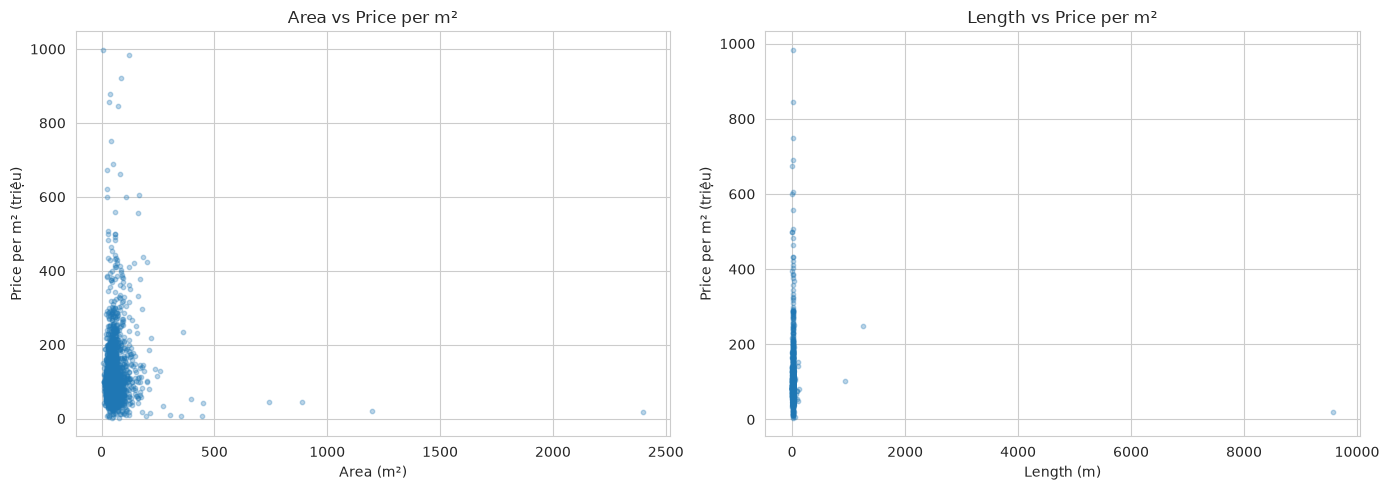

In [15]:
# Relationship: Area vs Price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample for better visualization
sample_df = df.dropna(subset=['Area', 'Price_per_m2']).sample(min(5000, len(df)), random_state=42)

axes[0].scatter(sample_df['Area'], sample_df['Price_per_m2'], alpha=0.3, s=10)
axes[0].set_xlabel('Area (m²)')
axes[0].set_ylabel('Price per m² (triệu)')
axes[0].set_title('Area vs Price per m²')

axes[1].scatter(sample_df['Length'], sample_df['Price_per_m2'], alpha=0.3, s=10)
axes[1].set_xlabel('Length (m)')
axes[1].set_ylabel('Price per m² (triệu)')
axes[1].set_title('Length vs Price per m²')

plt.tight_layout()
plt.show()

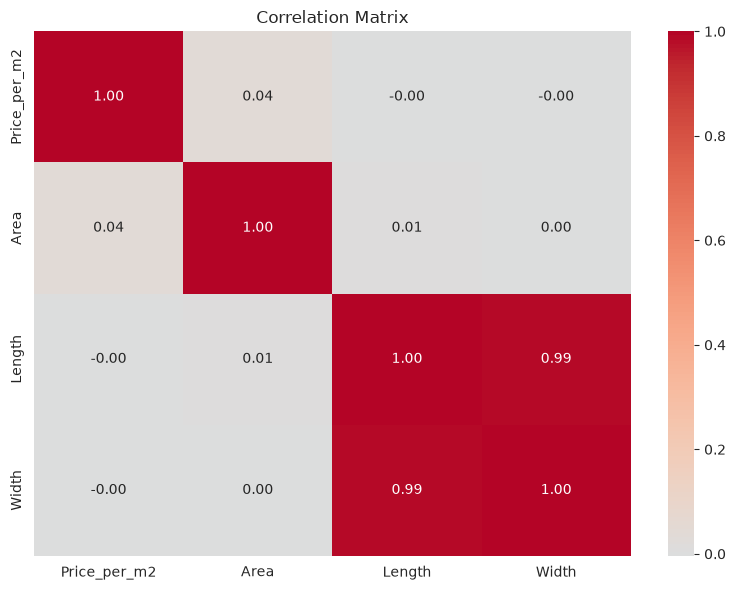

In [16]:
# Correlation heatmap
numerical_cols = ['Price_per_m2', 'Area', 'Length', 'Width']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

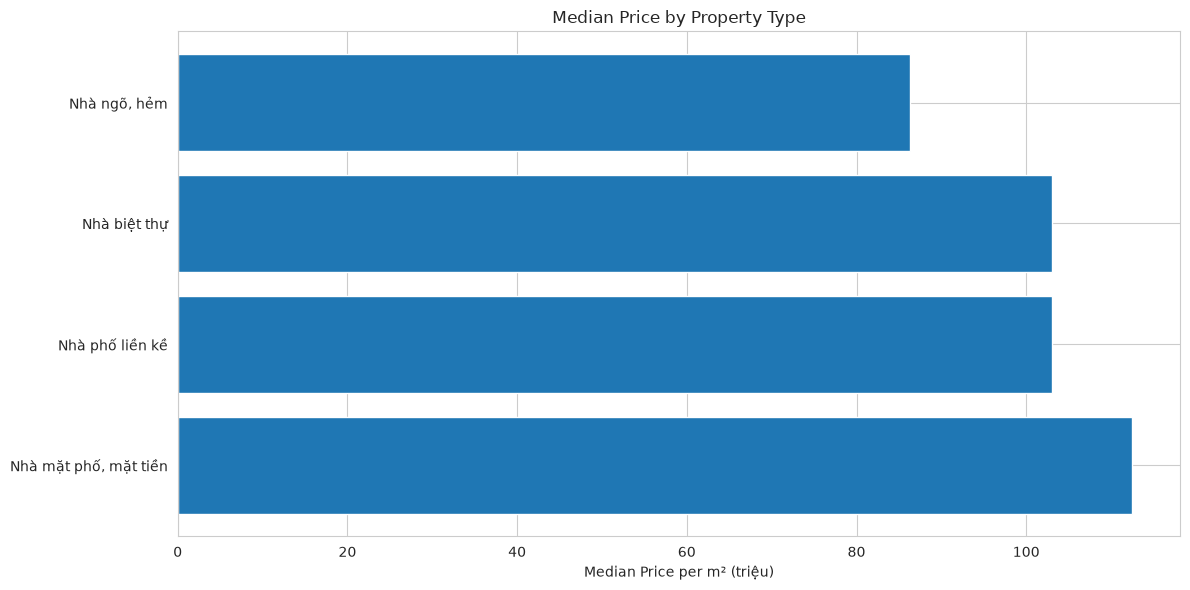

In [17]:
# Price by property type
property_type_price = df.groupby('Loại hình nhà ở')['Price_per_m2'].median().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(range(len(property_type_price)), property_type_price.values)
plt.yticks(range(len(property_type_price)), property_type_price.index)
plt.xlabel('Median Price per m² (triệu)')
plt.title('Median Price by Property Type')
plt.tight_layout()
plt.show()

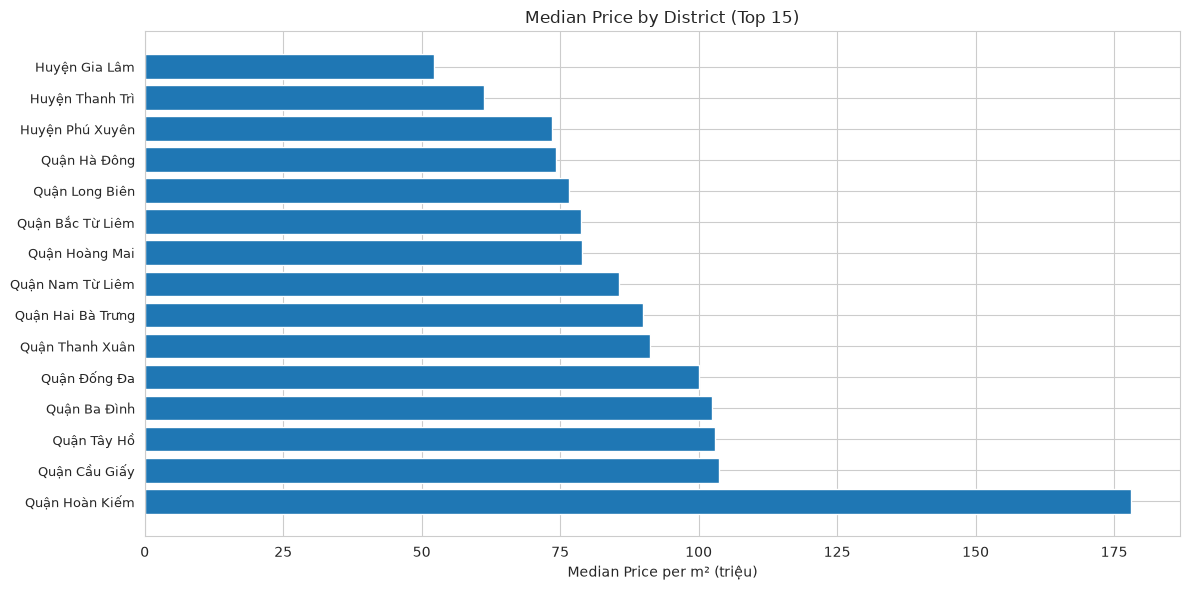

Key insights:
- Price range: 1.00 - 998.00 triệu/m²
- Most expensive district: Quận Hoàn Kiếm (178.00 triệu/m²)
- Median price: 90.00 triệu/m²


In [18]:
# Price by district (top 15)
district_price = df.groupby('Quận')['Price_per_m2'].median().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.barh(range(len(district_price)), district_price.values)
plt.yticks(range(len(district_price)), district_price.index, fontsize=9)
plt.xlabel('Median Price per m² (triệu)')
plt.title('Median Price by District (Top 15)')
plt.tight_layout()
plt.show()

print("Key insights:")
print(f"- Price range: {df['Price_per_m2'].min():.2f} - {df['Price_per_m2'].max():.2f} triệu/m²")
print(f"- Most expensive district: {district_price.index[0]} ({district_price.values[0]:.2f} triệu/m²)")
print(f"- Median price: {df['Price_per_m2'].median():.2f} triệu/m²")

# 11. Feature types

In [19]:
# Categorize features
numerical_features = ['Area', 'Length', 'Width']
categorical_features = ['Quận', 'Huyện', 'Loại hình nhà ở', 'Giấy tờ pháp lý', 'Số tầng', 'Số phòng ngủ']
target = 'Price_per_m2'

print("Feature Classification:")
print(f"\nNumerical Features ({len(numerical_features)}): {numerical_features}")
print(f"\nCategorical Features ({len(categorical_features)}): {categorical_features}")
print(f"\nTarget: {target}")

# Feature type summary
feature_summary = pd.DataFrame({
    'Feature': numerical_features + categorical_features,
    'Type': ['Numerical']*len(numerical_features) + ['Categorical']*len(categorical_features),
    'Missing %': [(df[f].isnull().sum()/len(df)*100) for f in numerical_features + categorical_features],
    'Unique Values': [df[f].nunique() for f in numerical_features + categorical_features]
})

print("\n" + feature_summary.to_string(index=False))

Feature Classification:

Numerical Features (3): ['Area', 'Length', 'Width']

Categorical Features (6): ['Quận', 'Huyện', 'Loại hình nhà ở', 'Giấy tờ pháp lý', 'Số tầng', 'Số phòng ngủ']

Target: Price_per_m2

        Feature        Type  Missing %  Unique Values
           Area   Numerical   0.002424            504
         Length   Numerical  75.966399            487
          Width   Numerical  57.034801            410
           Quận Categorical   0.002424             29
          Huyện Categorical   0.058184            309
Loại hình nhà ở Categorical   0.038789              4
Giấy tờ pháp lý Categorical  35.015819              3
        Số tầng Categorical  55.878396             29
   Số phòng ngủ Categorical   0.047274             11


# 12. Data representation

**Mathematical Representation:**

- Single observation: $\mathbf{x}_i = [x_{i1}, x_{i2}, ..., x_{id}]^T \in \mathbb{R}^d$
- Feature matrix: $\mathbf{X} \in \mathbb{R}^{N \times d}$
- Target vector: $\mathbf{y} \in \mathbb{R}^N$

**Transformation Pipeline:**

```
Raw Observation (Vietnamese text, categorical values)
    ↓
Parse & Clean (extract numerical values, handle Vietnamese)
    ↓
Feature Engineering (create derived features)
    ↓
Encoding (categorical → numerical)
    ↓
Scaling (standardization)
    ↓
Feature Vector x_i ∈ ℝ^d
    ↓
Feature Matrix X ∈ ℝ^(N×d)
    ↓
Model Input
```

In [20]:
# Show raw observation
print("=" * 60)
print("STEP 1: Raw Observation (single house record)")
print("=" * 60)
sample_idx = 10
raw_record = df.iloc[sample_idx]
print(raw_record[['Địa chỉ', 'Quận', 'Loại hình nhà ở', 'Diện tích', 'Số tầng', 'Giá/m2']])

STEP 1: Raw Observation (single house record)
Địa chỉ            Đường Tựu Liệt, Thị trấn Văn Điển, Huyện Thanh...
Quận                                                 Huyện Thanh Trì
Loại hình nhà ở                                         Nhà ngõ, hẻm
Diện tích                                                      35 m²
Số tầng                                                          NaN
Giá/m2                                                45,71 triệu/m²
Name: 10, dtype: object


In [21]:
# Demonstrate transformation for one record
print("\n" + "=" * 60)
print("STEP 2: After Parsing & Cleaning")
print("=" * 60)
print(f"Diện tích: '{raw_record['Diện tích']}' → {raw_record['Area']:.2f} m²")
print(f"Giá/m2: '{raw_record['Giá/m2']}' → {raw_record['Price_per_m2']:.2f} triệu")
print(f"Quận: '{raw_record['Quận']}' (categorical)")
print(f"Loại hình: '{raw_record['Loại hình nhà ở']}' (categorical)")


STEP 2: After Parsing & Cleaning
Diện tích: '35 m²' → 35.00 m²
Giá/m2: '45,71 triệu/m²' → 45.71 triệu
Quận: 'Huyện Thanh Trì' (categorical)
Loại hình: 'Nhà ngõ, hẻm' (categorical)


# 13. Feature engineering

In [22]:
# Create working dataframe
df_clean = df.copy()

# Drop rows with missing target
df_clean = df_clean.dropna(subset=['Price_per_m2'])

# Remove extreme outliers in target
Q1 = df_clean['Price_per_m2'].quantile(0.01)
Q3 = df_clean['Price_per_m2'].quantile(0.99)
df_clean = df_clean[(df_clean['Price_per_m2'] >= Q1) & (df_clean['Price_per_m2'] <= Q3)]

print(f"Records after cleaning: {len(df_clean):,} (from {len(df):,})")

# Feature engineering
# 1. Aspect ratio
df_clean['Aspect_Ratio'] = df_clean['Length'] / (df_clean['Width'] + 0.001)  # avoid division by zero

# 2. Calculated area from dimensions
df_clean['Calculated_Area'] = df_clean['Length'] * df_clean['Width']

# 3. Has dimensions flag
df_clean['Has_Dimensions'] = ((~df_clean['Length'].isna()) & (~df_clean['Width'].isna())).astype(int)

# 4. Has legal docs flag
df_clean['Has_Legal_Docs'] = (~df_clean['Giấy tờ pháp lý'].isna()).astype(int)

# 5. Simplify bedroom categories
def simplify_bedrooms(val):
    if pd.isna(val):
        return 'Unknown'
    val_str = str(val).lower()
    if 'nhiều hơn' in val_str or '10' in val_str:
        return '10+'
    elif 'phòng' in val_str:
        try:
            num = int(val_str.split()[0])
            return f"{num}"
        except:
            return 'Unknown'
    return 'Unknown'

df_clean['Bedrooms_Category'] = df_clean['Số phòng ngủ'].apply(simplify_bedrooms)

print("\nEngineered features:")
print("- Aspect_Ratio: Length/Width ratio")
print("- Calculated_Area: Length × Width")
print("- Has_Dimensions: Binary flag")
print("- Has_Legal_Docs: Binary flag")
print("- Bedrooms_Category: Simplified categories")

print(f"\nSample engineered features:")
print(df_clean[['Area', 'Length', 'Width', 'Aspect_Ratio', 'Has_Dimensions']].head())

Records after cleaning: 80,031 (from 82,497)

Engineered features:
- Aspect_Ratio: Length/Width ratio
- Calculated_Area: Length × Width
- Has_Dimensions: Binary flag
- Has_Legal_Docs: Binary flag
- Bedrooms_Category: Simplified categories

Sample engineered features:
   Area  Length  Width  Aspect_Ratio  Has_Dimensions
0  46.0     NaN    NaN           NaN               0
1  37.0     NaN    NaN           NaN               0
2  40.0   10.00    4.0      2.499375               1
3  51.0   12.75    4.0      3.186703               1
4  36.0    9.00    4.0      2.249438               1


# 14. Train/test split

In [23]:
# Select features for modeling
feature_cols = ['Area', 'Length', 'Width', 'Aspect_Ratio', 'Calculated_Area', 
                'Has_Dimensions', 'Has_Legal_Docs',
                'Quận', 'Loại hình nhà ở', 'Giấy tờ pháp lý', 'Bedrooms_Category']

# Prepare X and y
X = df_clean[feature_cols].copy()
y = df_clean['Price_per_m2'].copy()

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")
print(f"Train/Test split ratio: {len(X_train)/len(X_test):.1f}:1")
print(f"\nTarget distribution:")
print(f"  Train - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"  Test  - Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")

Training set: 64,024 samples
Test set: 16,007 samples
Train/Test split ratio: 4.0:1

Target distribution:
  Train - Mean: 99.08, Std: 44.16
  Test  - Mean: 99.21, Std: 44.13


# 15. Preprocessing pipeline

In [24]:
from sklearn.preprocessing import OneHotEncoder

# Define numerical and categorical columns
numerical_cols = ['Area', 'Length', 'Width', 'Aspect_Ratio', 'Calculated_Area', 
                  'Has_Dimensions', 'Has_Legal_Docs']
categorical_cols = ['Quận', 'Loại hình nhà ở', 'Giấy tờ pháp lý', 'Bedrooms_Category']

# Create preprocessing pipelines
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print("Preprocessing pipeline created:")
print(f"  - Numerical features: {len(numerical_cols)} → imputation + scaling")
print(f"  - Categorical features: {len(categorical_cols)} → imputation + one-hot encoding")

Preprocessing pipeline created:
  - Numerical features: 7 → imputation + scaling
  - Categorical features: 4 → imputation + one-hot encoding


In [25]:
# Fit and transform (on training data only - no leakage!)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\n" + "=" * 60)
print("DATA REPRESENTATION: From Raw to Model Input")
print("=" * 60)
print(f"\nOriginal features: {X_train.shape[1]}")
print(f"After preprocessing: {X_train_processed.shape[1]} dimensions")
print(f"\nFeature matrix dimensions:")
print(f"  X_train ∈ ℝ^({X_train_processed.shape[0]} × {X_train_processed.shape[1]})")
print(f"  X_test  ∈ ℝ^({X_test_processed.shape[0]} × {X_test_processed.shape[1]})")
print(f"\nSingle feature vector: x_i ∈ ℝ^{X_train_processed.shape[1]}")
print(f"\nFirst feature vector sample (first 10 dimensions):")
print(X_train_processed[0, :10])


DATA REPRESENTATION: From Raw to Model Input

Original features: 11
After preprocessing: 55 dimensions

Feature matrix dimensions:
  X_train ∈ ℝ^(64024 × 55)
  X_test  ∈ ℝ^(16007 × 55)

Single feature vector: x_i ∈ ℝ^55

First feature vector sample (first 10 dimensions):
[-0.50127396 -0.00603847 -0.00735925 -0.01003421 -0.00396962 -0.55476109
 -1.35789101  0.          0.          0.        ]


# 16. Baseline model

In [26]:
# Mean baseline predictor
y_train_mean = y_train.mean()
y_pred_baseline = np.full(len(y_test), y_train_mean)

# Baseline metrics
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("Baseline Model (Mean Predictor):")
print(f"  Prediction: {y_train_mean:.2f} triệu/m² for all samples")
print(f"  MAE:  {baseline_mae:.2f} triệu/m²")
print(f"  RMSE: {baseline_rmse:.2f} triệu/m²")
print(f"  R²:   {baseline_r2:.4f}")

# Store baseline results
results = {
    'Baseline (Mean)': {
        'MAE': baseline_mae,
        'MSE': baseline_rmse**2,
        'RMSE': baseline_rmse,
        'R2': baseline_r2
    }
}

Baseline Model (Mean Predictor):
  Prediction: 99.08 triệu/m² for all samples
  MAE:  29.51 triệu/m²
  RMSE: 44.13 triệu/m²
  R²:   -0.0000


# 17. Model training

In [27]:
# Train multiple regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10.0, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=20, 
                                           min_samples_split=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                    learning_rate=0.1, random_state=42)
}

print("Training models...\n")

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    model.fit(X_train_processed, y_train)
    print("✓")
    
    # Predictions
    y_pred = model.predict(X_test_processed)
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'model': model,
        'predictions': y_pred
    }
    
    print(f"  MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")

print("\nAll models trained successfully!")

Training models...

Training Linear Regression... ✓
  MAE: 25.11, RMSE: 36.46, R²: 0.3174
Training Ridge Regression... ✓
  MAE: 25.11, RMSE: 36.46, R²: 0.3173
Training Random Forest... ✓
  MAE: 23.34, RMSE: 34.95, R²: 0.3729
Training Gradient Boosting... ✓
  MAE: 23.78, RMSE: 35.19, R²: 0.3641

All models trained successfully!


# 18. Model comparison

In [28]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': [results[m]['MAE'] for m in results.keys()],
    'RMSE': [results[m]['RMSE'] for m in results.keys()],
    'R²': [results[m]['R2'] for m in results.keys()]
})

print("Model Comparison:")
print(comparison_df.to_string(index=False))

Model Comparison:
            Model       MAE      RMSE        R²
  Baseline (Mean) 29.506746 44.129910 -0.000008
Linear Regression 25.109150 36.459473  0.317413
 Ridge Regression 25.106782 36.461196  0.317349
    Random Forest 23.337431 34.945036  0.372941
Gradient Boosting 23.782294 35.190130  0.364115


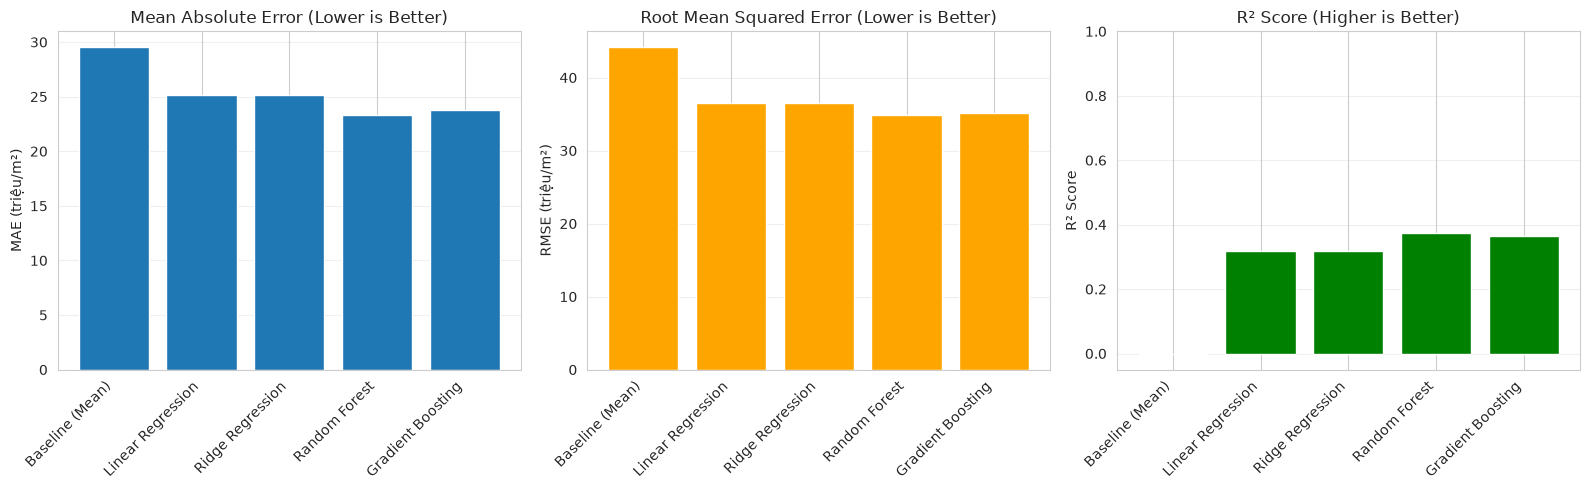


Best model by R²: Random Forest
  MAE:  23.34 triệu/m²
  RMSE: 34.95 triệu/m²
  R²:   0.3729


In [29]:
# Visualization: Model comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = comparison_df['Model']
x_pos = np.arange(len(model_names))

# MAE comparison
axes[0].bar(x_pos, comparison_df['MAE'])
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].set_ylabel('MAE (triệu/m²)')
axes[0].set_title('Mean Absolute Error (Lower is Better)')
axes[0].grid(axis='y', alpha=0.3)

# RMSE comparison
axes[1].bar(x_pos, comparison_df['RMSE'], color='orange')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1].set_ylabel('RMSE (triệu/m²)')
axes[1].set_title('Root Mean Squared Error (Lower is Better)')
axes[1].grid(axis='y', alpha=0.3)

# R² comparison
axes[2].bar(x_pos, comparison_df['R²'], color='green')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(model_names, rotation=45, ha='right')
axes[2].set_ylabel('R² Score')
axes[2].set_title('R² Score (Higher is Better)')
axes[2].set_ylim([comparison_df['R²'].min() - 0.05, 1.0])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Best model
best_model_name = comparison_df.loc[comparison_df['R²'].idxmax(), 'Model']
print(f"\nBest model by R²: {best_model_name}")
print(f"  MAE:  {comparison_df.loc[comparison_df['R²'].idxmax(), 'MAE']:.2f} triệu/m²")
print(f"  RMSE: {comparison_df.loc[comparison_df['R²'].idxmax(), 'RMSE']:.2f} triệu/m²")
print(f"  R²:   {comparison_df.loc[comparison_df['R²'].idxmax(), 'R²']:.4f}")

# 19. Evaluation

In [30]:
# Select best model for detailed evaluation
best_model_name = max(results.keys(), key=lambda k: results[k]['R2'] if k != 'Baseline (Mean)' else -np.inf)
best_model = results[best_model_name]['model']
y_pred_best = results[best_model_name]['predictions']

print(f"Best Model: {best_model_name}")
print("\nTest Set Performance:")
print(f"  MAE:  {results[best_model_name]['MAE']:.2f} triệu/m²")
print(f"  MSE:  {results[best_model_name]['MSE']:.2f}")
print(f"  RMSE: {results[best_model_name]['RMSE']:.2f} triệu/m²")
print(f"  R²:   {results[best_model_name]['R2']:.4f}")

print(f"\nImprovement over baseline:")
print(f"  MAE reduction:  {(1 - results[best_model_name]['MAE']/results['Baseline (Mean)']['MAE'])*100:.1f}%")
print(f"  RMSE reduction: {(1 - results[best_model_name]['RMSE']/results['Baseline (Mean)']['RMSE'])*100:.1f}%")

Best Model: Random Forest

Test Set Performance:
  MAE:  23.34 triệu/m²
  MSE:  1221.16
  RMSE: 34.95 triệu/m²
  R²:   0.3729

Improvement over baseline:
  MAE reduction:  20.9%
  RMSE reduction: 20.8%


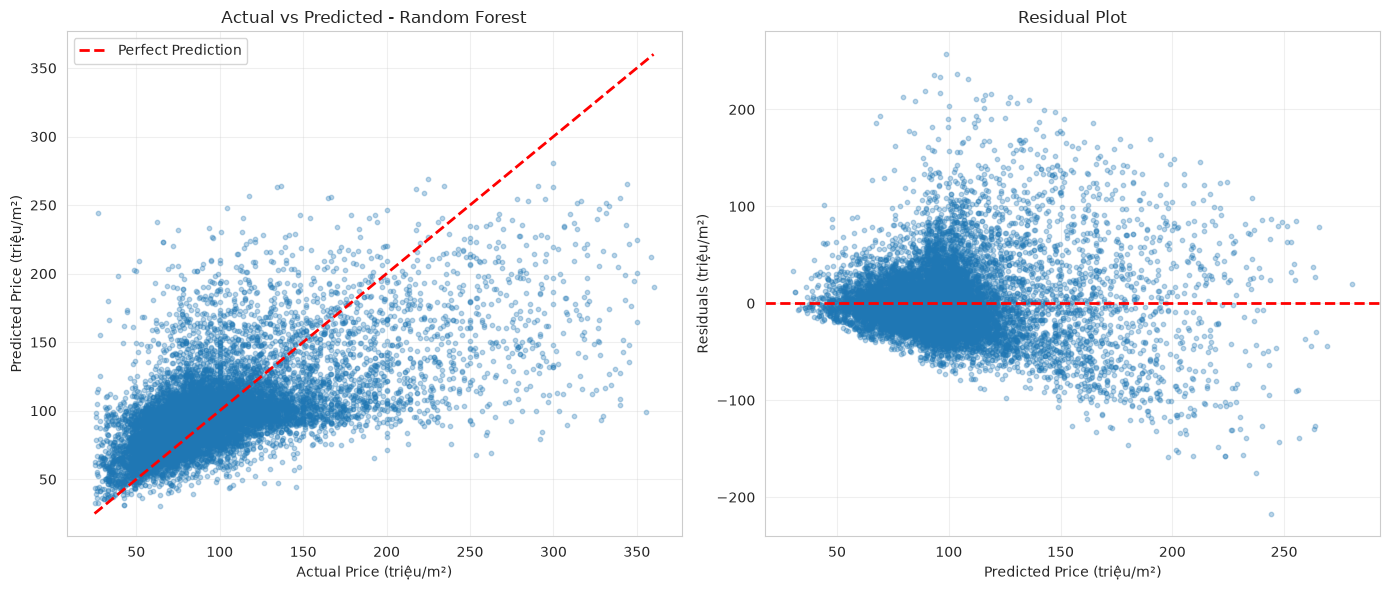

In [31]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (triệu/m²)')
axes[0].set_ylabel('Predicted Price (triệu/m²)')
axes[0].set_title(f'Actual vs Predicted - {best_model_name}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residual plot
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.3, s=10)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price (triệu/m²)')
axes[1].set_ylabel('Residuals (triệu/m²)')
axes[1].set_title('Residual Plot')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

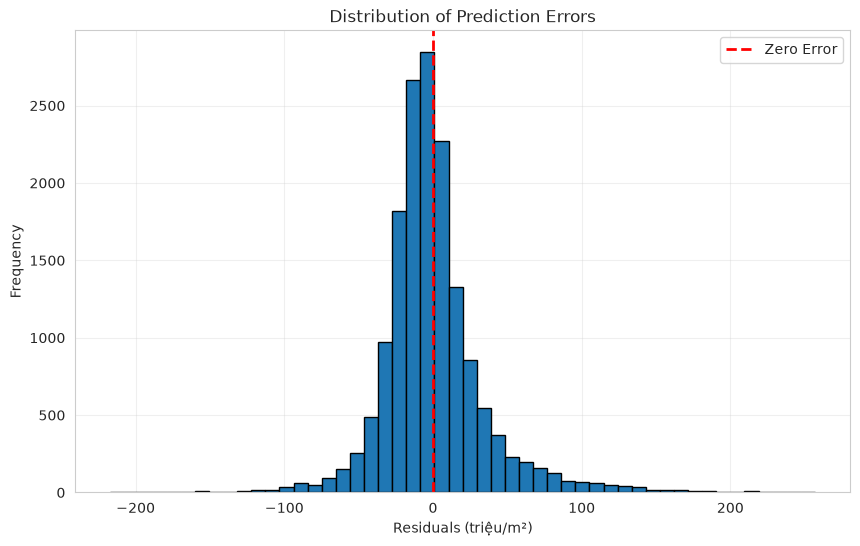

Residual statistics:
  Mean: 0.02 triệu/m²
  Std:  34.95 triệu/m²
  Min:  -216.95 triệu/m²
  Max:  256.88 triệu/m²


In [32]:
# Residual distribution
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, edgecolor='black')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
plt.xlabel('Residuals (triệu/m²)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Residual statistics:")
print(f"  Mean: {residuals.mean():.2f} triệu/m²")
print(f"  Std:  {residuals.std():.2f} triệu/m²")
print(f"  Min:  {residuals.min():.2f} triệu/m²")
print(f"  Max:  {residuals.max():.2f} triệu/m²")

# 20. Error analysis

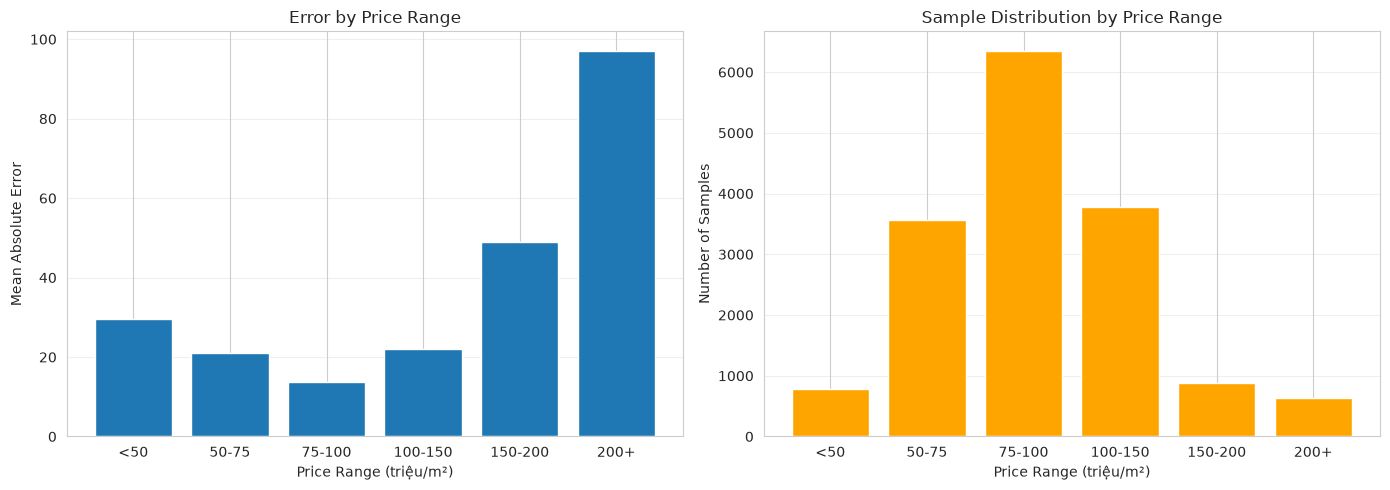

Error by price range:
                  mean        std  count
Price_Range                             
<50          29.465209  22.887634    790
50-75        21.131083  16.799822   3560
75-100       13.598848  15.119604   6354
100-150      22.075970  17.505865   3778
150-200      48.843755  26.493584    888
200+         97.134588  48.181399    637


In [33]:
# Error analysis by price range
error_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_best,
    'Error': np.abs(y_test.values - y_pred_best),
    'Residual': residuals
})

# Create price bins
error_df['Price_Range'] = pd.cut(error_df['Actual'], 
                                  bins=[0, 50, 75, 100, 150, 200, 500],
                                  labels=['<50', '50-75', '75-100', '100-150', '150-200', '200+'])

# Error by price range
error_by_range = error_df.groupby('Price_Range')['Error'].agg(['mean', 'std', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean error by price range
axes[0].bar(range(len(error_by_range)), error_by_range['mean'])
axes[0].set_xticks(range(len(error_by_range)))
axes[0].set_xticklabels(error_by_range.index)
axes[0].set_xlabel('Price Range (triệu/m²)')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_title('Error by Price Range')
axes[0].grid(axis='y', alpha=0.3)

# Sample count by price range
axes[1].bar(range(len(error_by_range)), error_by_range['count'], color='orange')
axes[1].set_xticks(range(len(error_by_range)))
axes[1].set_xticklabels(error_by_range.index)
axes[1].set_xlabel('Price Range (triệu/m²)')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Sample Distribution by Price Range')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Error by price range:")
print(error_by_range)

In [34]:
# Identify worst predictions
error_df_sorted = error_df.sort_values('Error', ascending=False)

print("Top 10 worst predictions:")
print(error_df_sorted[['Actual', 'Predicted', 'Error']].head(10).to_string())

print("\nBest 10 predictions:")
print(error_df_sorted[['Actual', 'Predicted', 'Error']].tail(10).to_string())

Top 10 worst predictions:
       Actual   Predicted       Error
26180  355.77   98.892711  256.877289
29371  340.00  103.824374  236.175626
75479  328.57   93.279258  235.290742
66483  330.00   96.133403  233.866597
1435   340.00  108.650598  231.349402
37273  308.33   89.296955  219.033045
31710   27.20  244.149843  216.949843
10888  312.50   96.042535  216.457465
29694  334.62  119.060907  215.559093
77971  330.77  116.406253  214.363747

Best 10 predictions:
       Actual   Predicted     Error
40294   80.00   79.975677  0.024323
21570  113.04  113.061191  0.021191
20903   70.00   69.980236  0.019764
45259   80.00   80.016092  0.016092
80136   80.00   80.016092  0.016092
24806   52.67   52.655521  0.014479
78395   81.25   81.242918  0.007082
58284   59.38   59.375492  0.004508
80105   72.50   72.498339  0.001661
12715   62.14   62.138884  0.001116


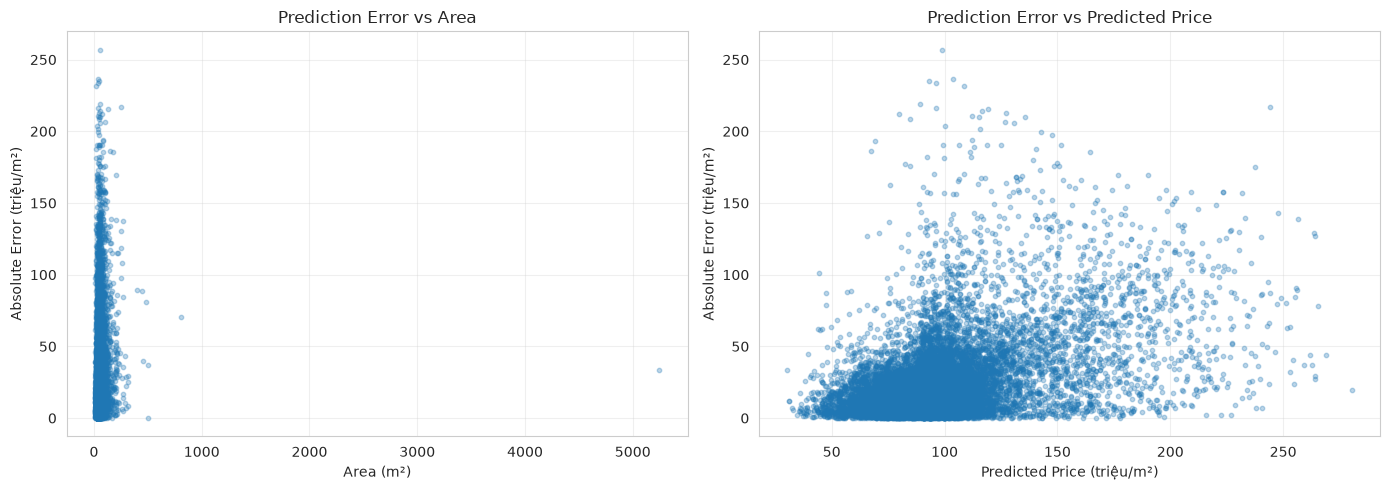


Key insights:
- Higher errors in extreme price ranges
- Model performs best in mid-range prices (50-150 triệu/m²)
- Error variance increases with price (heteroscedasticity)


In [35]:
# Error vs Area relationship
X_test_original = X_test.copy()
X_test_original['Error'] = error_df['Error'].values
X_test_original['Predicted'] = y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error vs Area
axes[0].scatter(X_test_original['Area'], X_test_original['Error'], alpha=0.3, s=10)
axes[0].set_xlabel('Area (m²)')
axes[0].set_ylabel('Absolute Error (triệu/m²)')
axes[0].set_title('Prediction Error vs Area')
axes[0].grid(alpha=0.3)

# Error vs Predicted Price
axes[1].scatter(X_test_original['Predicted'], X_test_original['Error'], alpha=0.3, s=10)
axes[1].set_xlabel('Predicted Price (triệu/m²)')
axes[1].set_ylabel('Absolute Error (triệu/m²)')
axes[1].set_title('Prediction Error vs Predicted Price')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey insights:")
print("- Higher errors in extreme price ranges")
print("- Model performs best in mid-range prices (50-150 triệu/m²)")
print("- Error variance increases with price (heteroscedasticity)")

# 21. Model selection

In [36]:
# Final model selection
print("Model Selection Criteria:")
print("  1. Predictive performance (R², MAE, RMSE)")
print("  2. Generalization ability")
print("  3. Robustness to outliers")

print("\n" + "="*60)
print(f"SELECTED MODEL: {best_model_name}")
print("="*60)

print(f"\nFinal Test Metrics:")
print(f"  MAE:  {results[best_model_name]['MAE']:.2f} triệu/m²")
print(f"  RMSE: {results[best_model_name]['RMSE']:.2f} triệu/m²")
print(f"  R²:   {results[best_model_name]['R2']:.4f}")

# Create final pipeline with best model
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model)
])

# Fit on full training data
final_pipeline.fit(X_train, y_train)

print("\n✓ Final pipeline created and fitted")

Model Selection Criteria:
  1. Predictive performance (R², MAE, RMSE)
  2. Generalization ability
  3. Robustness to outliers

SELECTED MODEL: Random Forest

Final Test Metrics:
  MAE:  23.34 triệu/m²
  RMSE: 34.95 triệu/m²
  R²:   0.3729

✓ Final pipeline created and fitted


# 22. Model persistence

In [37]:
import os

# Create models directory
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save the complete pipeline
model_path = os.path.join(models_dir, 'house_price_model.pkl')
joblib.dump(final_pipeline, model_path)

print(f"Model saved to: {model_path}")
print(f"File size: {os.path.getsize(model_path) / 1024:.2f} KB")

# Save metadata
metadata = {
    'model_name': best_model_name,
    'features': feature_cols,
    'test_mae': results[best_model_name]['MAE'],
    'test_rmse': results[best_model_name]['RMSE'],
    'test_r2': results[best_model_name]['R2'],
    'training_samples': len(X_train),
    'test_samples': len(X_test)
}

metadata_path = os.path.join(models_dir, 'model_metadata.pkl')
joblib.dump(metadata, metadata_path)

print(f"Metadata saved to: {metadata_path}")

Model saved to: ../models/house_price_model.pkl
File size: 43724.50 KB
Metadata saved to: ../models/model_metadata.pkl


In [38]:
# Verify saved model
loaded_pipeline = joblib.load(model_path)
loaded_metadata = joblib.load(metadata_path)

print("✓ Model loaded successfully")
print(f"  Model: {loaded_metadata['model_name']}")
print(f"  Features: {len(loaded_metadata['features'])}")
print(f"  Test R²: {loaded_metadata['test_r2']:.4f}")

# Verify predictions
y_pred_loaded = loaded_pipeline.predict(X_test)
mae_loaded = mean_absolute_error(y_test, y_pred_loaded)

print(f"\nVerification: MAE match = {abs(results[best_model_name]['MAE'] - mae_loaded) < 0.01}")

✓ Model loaded successfully
  Model: Random Forest
  Features: 11
  Test R²: 0.3729

Verification: MAE match = True


# 23. Inference test

In [39]:
# Test inference with sample data
print("Testing inference pipeline...\n")

# Create sample houses
sample_houses = [
    {
        'Area': 50.0, 'Length': 10.0, 'Width': 5.0,
        'Aspect_Ratio': 2.0, 'Calculated_Area': 50.0,
        'Has_Dimensions': 1, 'Has_Legal_Docs': 1,
        'Quận': 'Quận Ba Đình',
        'Loại hình nhà ở': 'Nhà ngõ, hẻm',
        'Giấy tờ pháp lý': 'Đã có sổ',
        'Bedrooms_Category': '3'
    },
    {
        'Area': 80.0, 'Length': 16.0, 'Width': 5.0,
        'Aspect_Ratio': 3.2, 'Calculated_Area': 80.0,
        'Has_Dimensions': 1, 'Has_Legal_Docs': 0,
        'Quận': 'Quận Hoàn Kiếm',
        'Loại hình nhà ở': 'Nhà mặt phố, mặt tiền',
        'Giấy tờ pháp lý': None,
        'Bedrooms_Category': '4'
    },
    {
        'Area': 35.0, 'Length': None, 'Width': None,
        'Aspect_Ratio': None, 'Calculated_Area': None,
        'Has_Dimensions': 0, 'Has_Legal_Docs': 1,
        'Quận': 'Quận Thanh Xuân',
        'Loại hình nhà ở': 'Nhà ngõ, hẻm',
        'Giấy tờ pháp lý': 'Đã có sổ',
        'Bedrooms_Category': '2'
    }
]

new_data = pd.DataFrame(sample_houses)
print("Input:")
print(new_data[['Area', 'Quận', 'Loại hình nhà ở']].to_string(index=False))

Testing inference pipeline...

Input:
 Area            Quận       Loại hình nhà ở
 50.0    Quận Ba Đình          Nhà ngõ, hẻm
 80.0  Quận Hoàn Kiếm Nhà mặt phố, mặt tiền
 35.0 Quận Thanh Xuân          Nhà ngõ, hẻm


In [40]:
# Make predictions
predictions = loaded_pipeline.predict(new_data)

print("\n" + "="*60)
print("INFERENCE RESULTS")
print("="*60)

for i, (house, pred) in enumerate(zip(sample_houses, predictions), 1):
    print(f"\nHouse {i}:")
    print(f"  Location: {house['Quận']}")
    print(f"  Area: {house['Area']} m²")
    print(f"  Type: {house['Loại hình nhà ở']}")
    print(f"  → Predicted: {pred:.2f} triệu/m²")
    print(f"  → Total: {pred * house['Area']:.0f} triệu")


INFERENCE RESULTS

House 1:
  Location: Quận Ba Đình
  Area: 50.0 m²
  Type: Nhà ngõ, hẻm
  → Predicted: 101.45 triệu/m²
  → Total: 5073 triệu

House 2:
  Location: Quận Hoàn Kiếm
  Area: 80.0 m²
  Type: Nhà mặt phố, mặt tiền
  → Predicted: 181.00 triệu/m²
  → Total: 14480 triệu

House 3:
  Location: Quận Thanh Xuân
  Area: 35.0 m²
  Type: Nhà ngõ, hẻm
  → Predicted: 80.86 triệu/m²
  → Total: 2830 triệu


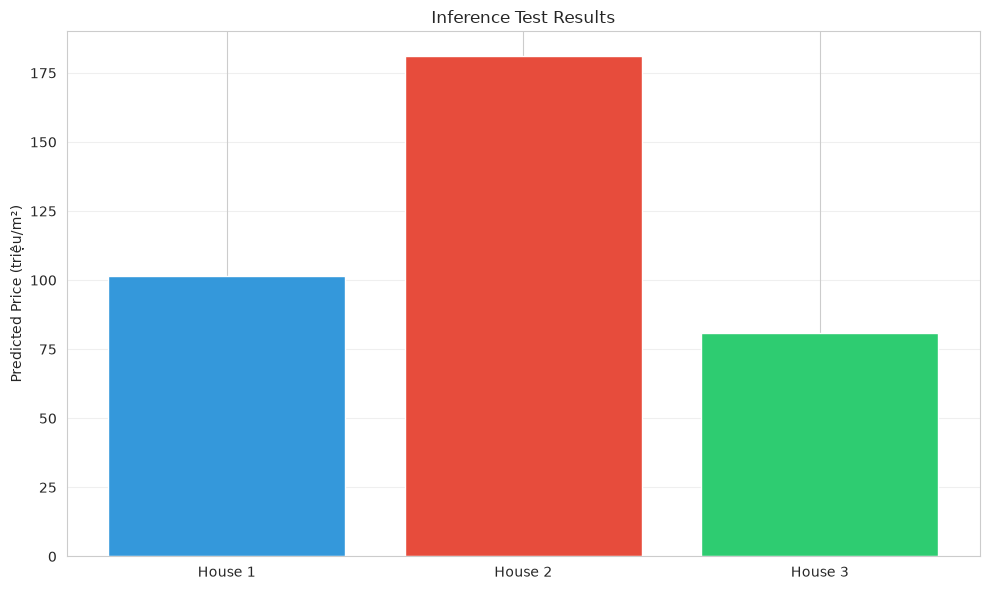


✓ Inference test successful
✓ Model ready for deployment


In [41]:
# Visualize
plt.figure(figsize=(10, 6))
plt.bar(range(len(predictions)), predictions, color=['#3498db', '#e74c3c', '#2ecc71'])
plt.xticks(range(len(predictions)), [f"House {i+1}" for i in range(len(predictions))])
plt.ylabel('Predicted Price (triệu/m²)')
plt.title('Inference Test Results')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Inference test successful")
print("✓ Model ready for deployment")